In [1]:
import pandas as pd

In [3]:
dataset=pd.read_csv("preprocessed_social_interaction.csv")

In [4]:
dataset

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label,gender_male,platform_usage_Instagram,platform_usage_TikTok
0,14,7.9,7.4,2.9,3.01,1.5,1,2,2,1,0,True,True,False
1,19,1.9,8.0,2.9,3.22,0.8,0,8,1,10,0,False,False,True
2,17,1.3,7.6,0.5,3.92,0.0,0,2,4,2,0,False,True,False
3,15,7.4,6.9,1.6,3.48,0.8,2,1,7,9,0,True,False,True
4,15,4.7,4.9,3.0,2.37,1.4,2,3,5,2,0,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,18,6.8,6.6,2.0,2.76,1.0,1,3,4,4,0,False,True,False
1196,16,2.3,8.0,1.9,2.12,0.4,0,7,4,4,0,True,False,False
1197,14,1.7,8.7,0.7,3.98,0.8,0,1,1,1,0,False,False,False
1198,15,3.9,8.5,2.1,3.19,0.6,0,7,9,9,0,True,False,False


# 1.Relation between academic_performance and daily_social_media_hours.

In [5]:
dataset.corr()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label,gender_male,platform_usage_Instagram,platform_usage_TikTok
age,1.000000,-0.006635,0.001530,0.075612,-0.013973,0.011086,-0.059527,-0.031208,0.026363,0.038265,0.010973,0.010785,-0.022195,0.012719
daily_social_media_hours,-0.006635,1.000000,-0.009472,0.035777,0.013179,0.025546,0.029224,0.030698,0.027835,-0.024964,0.175201,0.011382,0.008076,-0.001914
sleep_hours,0.001530,-0.009472,1.000000,0.010235,0.021866,0.012701,-0.021762,-0.010979,-0.011879,-0.054838,-0.190630,-0.031783,-0.004883,-0.001556
screen_time_before_sleep,0.075612,0.035777,0.010235,1.000000,-0.034715,-0.026450,-0.008634,-0.008650,-0.010344,0.028884,-0.016502,-0.026776,-0.028134,0.023590
academic_performance,-0.013973,0.013179,0.021866,-0.034715,1.000000,0.023312,0.011222,-0.000600,-0.064379,0.029354,0.001441,-0.017194,0.006404,0.011781
physical_activity,0.011086,0.025546,0.012701,-0.026450,0.023312,1.000000,-0.011312,0.012159,-0.022233,0.026200,-0.017598,0.017139,0.032109,-0.039452
social_interaction_level,-0.059527,0.029224,-0.021762,-0.008634,0.011222,-0.011312,1.000000,-0.003183,-0.001416,0.008547,0.005110,0.036966,0.006309,-0.062636
stress_level,-0.031208,0.030698,-0.010979,-0.008650,-0.000600,0.012159,-0.003183,1.000000,0.015811,-0.000129,0.170474,0.007935,0.013169,-0.038083
anxiety_level,0.026363,0.027835,-0.011879,-0.010344,-0.064379,-0.022233,-0.001416,0.015811,1.000000,0.031154,0.169566,-0.017236,0.008190,0.027623
addiction_level,0.038265,-0.024964,-0.054838,0.028884,0.029354,0.026200,0.008547,-0.000129,0.031154,1.000000,-0.013952,0.027414,0.004211,0.012593


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
correlation = dataset['academic_performance'].corr(dataset['daily_social_media_hours'])

In [8]:
correlation

0.013178979116841252

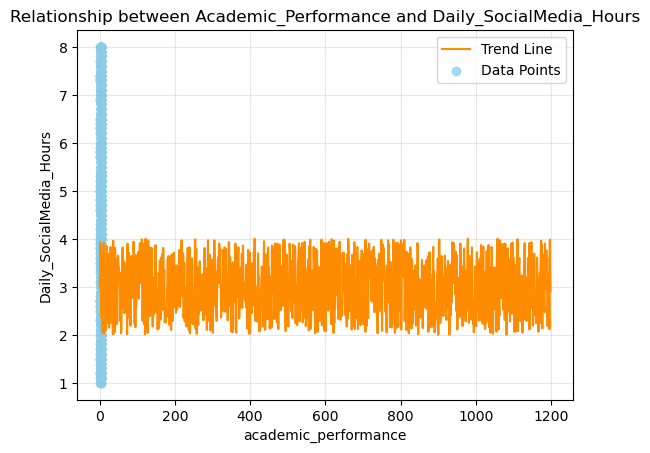

In [9]:
plt.plot(dataset['academic_performance'], color='darkorange', label=f'Trend Line')
plt.scatter(dataset['academic_performance'], dataset['daily_social_media_hours'], color='skyblue', alpha=0.7, label='Data Points')
plt.title('Relationship between Academic_Performance and Daily_SocialMedia_Hours')
plt.xlabel('academic_performance')
plt.ylabel('Daily_SocialMedia_Hours')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 2.Test the similarity of the screen_time_before_sleep with respect to addiction_level and platform_usage_instagram.

In [ ]:
!pip install statsmodels

In [10]:
import statsmodels.formula.api as smf
model = smf.ols('screen_time_before_sleep ~ addiction_level * platform_usage_Instagram', data=dataset).fit()
print(model.summary().tables[1])

                                                       coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------------
Intercept                                            1.7210      0.056     30.697      0.000       1.611       1.831
platform_usage_Instagram[T.True]                    -0.0633      0.097     -0.655      0.512      -0.253       0.126
addiction_level                                      0.0061      0.009      0.678      0.498      -0.012       0.024
addiction_level:platform_usage_Instagram[T.True]     0.0037      0.015      0.240      0.811      -0.027       0.034


In [11]:
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
corr_matrix = dataset[['screen_time_before_sleep', 'addiction_level', 'platform_usage_Instagram']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".3f", linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.subplot(1, 2, 2)
sns.barplot(x='addiction_level', y='screen_time_before_sleep', hue='platform_usage_Instagram', data=dataset, palette='Set2', errorbar=None)
plt.title('Average Screen Time by Addiction Level & Instagram Use')
plt.xlabel('Addiction Level')
plt.ylabel('Avg Screen Time Before Sleep (Hours)')

plt.tight_layout()
plt.savefig('comprehensive_similarity_analysis.png', dpi=100)
plt.close()
print("Generated comprehensive_similarity_analysis.png")

Generated comprehensive_similarity_analysis.png


# 3.Parameter highly correlated with anxiety_level.

In [13]:
df_correlated = dataset.dropna(subset=['anxiety_level'])

In [14]:
df_correlated

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label,gender_male,platform_usage_Instagram,platform_usage_TikTok
0,14,7.9,7.4,2.9,3.01,1.5,1,2,2,1,0,True,True,False
1,19,1.9,8.0,2.9,3.22,0.8,0,8,1,10,0,False,False,True
2,17,1.3,7.6,0.5,3.92,0.0,0,2,4,2,0,False,True,False
3,15,7.4,6.9,1.6,3.48,0.8,2,1,7,9,0,True,False,True
4,15,4.7,4.9,3.0,2.37,1.4,2,3,5,2,0,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,18,6.8,6.6,2.0,2.76,1.0,1,3,4,4,0,False,True,False
1196,16,2.3,8.0,1.9,2.12,0.4,0,7,4,4,0,True,False,False
1197,14,1.7,8.7,0.7,3.98,0.8,0,1,1,1,0,False,False,False
1198,15,3.9,8.5,2.1,3.19,0.6,0,7,9,9,0,True,False,False


In [15]:
df_correlated.columns

Index(['age', 'daily_social_media_hours', 'sleep_hours',
       'screen_time_before_sleep', 'academic_performance', 'physical_activity',
       'social_interaction_level', 'stress_level', 'anxiety_level',
       'addiction_level', 'depression_label', 'gender_male',
       'platform_usage_Instagram', 'platform_usage_TikTok'],
      dtype='object')

In [17]:
numeric_cols = ['age', 'daily_social_media_hours', 'sleep_hours',
       'screen_time_before_sleep', 'academic_performance', 'physical_activity',
       'social_interaction_level', 'stress_level', 'anxiety_level',
       'addiction_level', 'depression_label', 'gender_male',
       'platform_usage_Instagram', 'platform_usage_TikTok']
corr_matrix = df_correlated[numeric_cols].corr()

In [19]:
print("Correlation with social_interaction_level_medium:")
print(corr_matrix['anxiety_level'].sort_values(ascending=False))

Correlation with social_interaction_level_medium:
anxiety_level               1.000000
depression_label            0.169566
addiction_level             0.031154
daily_social_media_hours    0.027835
platform_usage_TikTok       0.027623
age                         0.026363
stress_level                0.015811
platform_usage_Instagram    0.008190
social_interaction_level   -0.001416
screen_time_before_sleep   -0.010344
sleep_hours                -0.011879
gender_male                -0.017236
physical_activity          -0.022233
academic_performance       -0.064379
Name: anxiety_level, dtype: float64


In [ ]:
#Among numerical factors, depression_label is the most highly correlated parameter with anxiety_level.

# 4.ANOVA Between gender_male and Physical activity at 5% significance level using hypothesis testing.

In [20]:
from scipy import stats
dataset=pd.read_csv("preprocessed_social_interaction.csv")
f_stat, p_value = stats.f_oneway(dataset['gender_male'], dataset['physical_activity'])

In [21]:
print(f"F-Statistic: {f_stat}")
print(f"p-value: {p_value}")
alpha = 0.05
if p_value < alpha:
    print("Decision: Reject the Null Hypothesis. The means are significantly DIFFERENT.")
else:
    print("Decision: Fail to Reject the Null Hypothesis. The means are SIMILAR.")

F-Statistic: 513.4285648743797
p-value: 3.6630868423602433e-103
Decision: Reject the Null Hypothesis. The means are significantly DIFFERENT.


# 5.Plot the graph

C:\Users\This PC\AppData\Local\Temp\ipykernel_10788\4219481694.py:6: UserWarning: Glyph 9 (	) missing from current font.
  plt.tight_layout()
D:\Anaconda3\Lib\site-packages\IPython\core\events.py:93: UserWarning: Glyph 9 (	) missing from current font.
  func(*args, **kwargs)
D:\Anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 9 (	) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


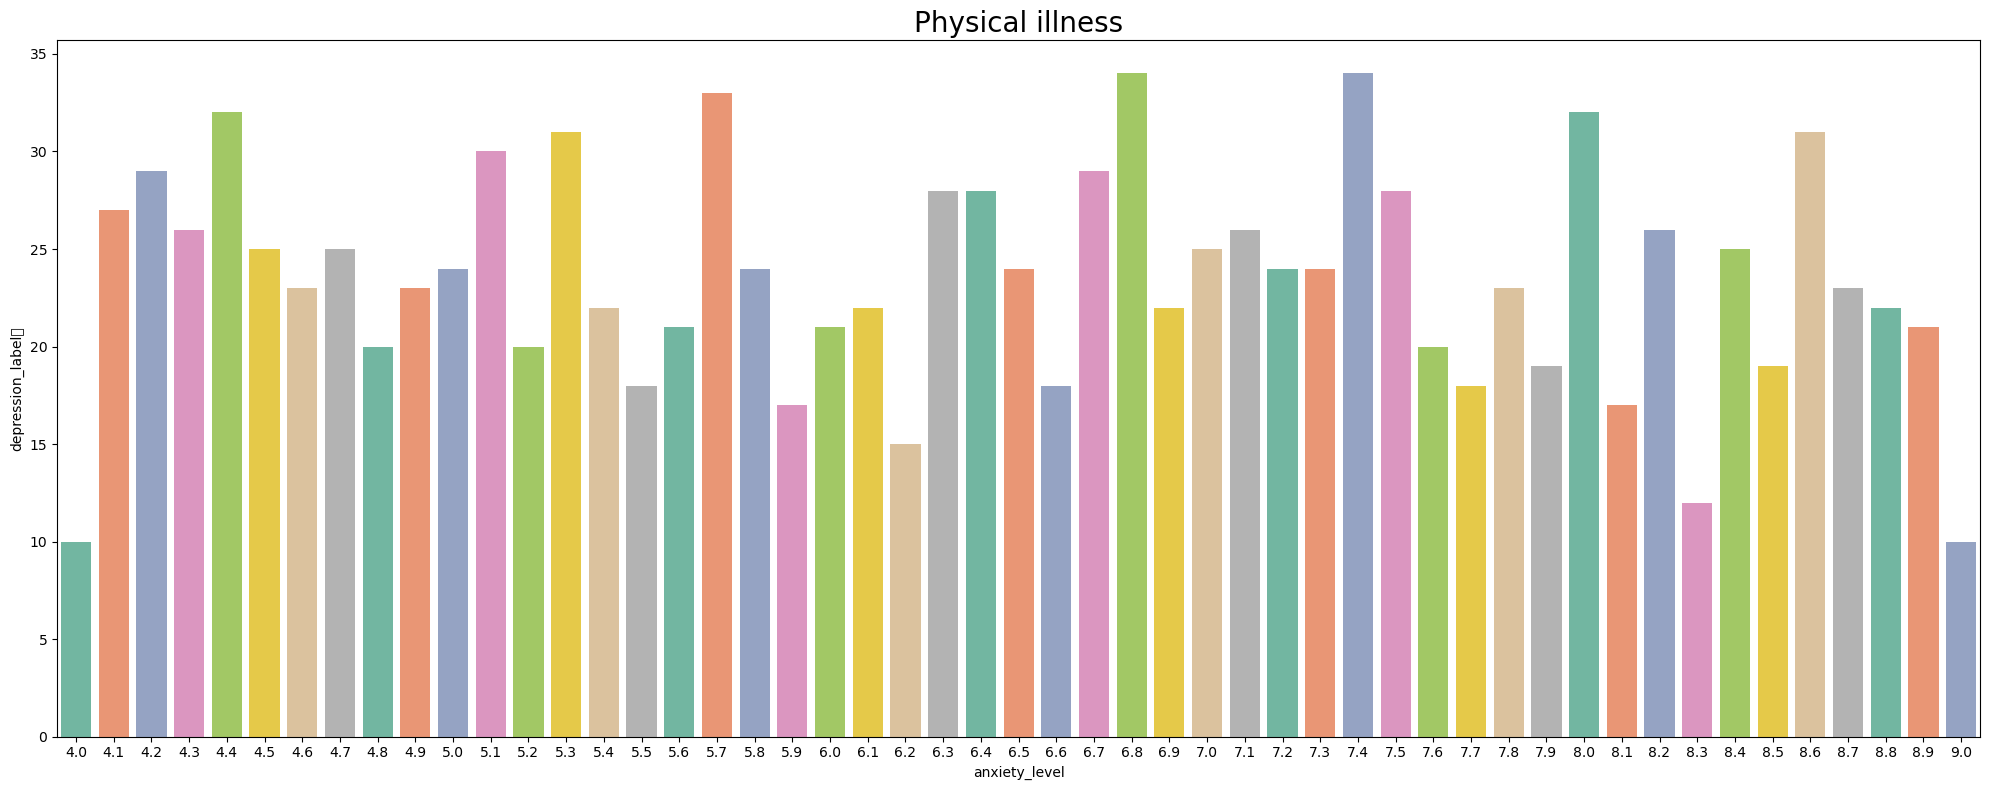

In [22]:
fig, ax = plt.subplots(figsize=(20,8)) #Setting up the plotting area (20 inches wide, 8 inches high)
sns.countplot(data=dataset, x='sleep_hours', palette='Set2', ax=ax) #Creating a simple count plot of the 'sleep_hours' column
ax.set_title('Physical illness', fontsize=20) #Adding clear labels and a title
ax.set_xlabel('anxiety_level')
ax.set_ylabel('depression_label	')
plt.tight_layout()